# Hybrid Retrieval with Reciprocal Rank Fusion

**Docker image**: `ml4t-gpu`

**Chapter 22: RAG for Financial Research** (Section 22.5)

This notebook demonstrates hybrid retrieval combining:

1. **Semantic search** - Dense embeddings capture meaning
2. **Keyword search (BM25)** - Sparse retrieval for exact matches
3. **Reciprocal Rank Fusion (RRF)** - Combining ranked lists

**Learning Objectives**:
- Implement a simple hybrid retrieval stack combining semantic and lexical search.
- Inspect when BM25, dense retrieval, and RRF succeed on different query types.
- Connect retrieval design choices to the finance-specific failure modes in Chapter 22.

**Prerequisites**: SP100 10-K filings (`data/equities/fundamentals/10k/sp100/`).
Familiarity with embeddings from `02_domain_embeddings_comparison`
is helpful but not required.

## Key Findings (Preview)
- Hybrid retrieval broadens first-stage recall by combining lexical and semantic signals
- Reranking is evaluated as a production pattern against an explicitly lexical
  proxy, not as a human-rated deployment benchmark
- BM25 excels at exact symbols, figures, and entity names
- Semantic search captures conceptual similarity and paraphrases
- Fixed-k RRF is score-calibration-free and robust, but not always sufficient on its own

## 1. Setup and Imports

These parameters control query count and retrieval depth so the comparison
stays reproducible across lexical, dense, fused, and reranked pipelines.

In [1]:
"""Hybrid Retrieval - BM25 + semantic search with Reciprocal Rank Fusion."""

import re
import warnings
from collections import defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch

# Visualization
from IPython.display import Markdown, display
from plotly.subplots import make_subplots

# ML4T configuration
from data import load_sec_filings
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_palette

In [2]:
MAX_QUERIES = 0
MAX_DOCUMENTS = 0
TOP_K = 10
# Spec from §22.5: retrieve a broad candidate pool, rerank, pass a small set
# to generation. RERANK_CANDIDATES is the pool size the cross-encoder scores;
# FINAL_TOP_K is the cut delivered to the LLM in production. Single-stage
# retrievers are still evaluated at TOP_K so the cross-architecture comparison
# stays apples-to-apples.
RERANK_CANDIDATES = 50
FINAL_TOP_K = 5
REQUIRE_GPU = True
SEED = 42

In [3]:
# Must remain immediately after the parameters cell so a Papermill SEED
# override re-seeds before any randomness is consumed downstream.
set_global_seeds(SEED)

if REQUIRE_GPU and not torch.cuda.is_available():
    raise RuntimeError("This production retrieval benchmark requires a CUDA-capable GPU.")
RETRIEVAL_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dense retrieval device: {RETRIEVAL_DEVICE}")

Dense retrieval device: cuda


In [4]:
print(f"Query cap: {MAX_QUERIES if MAX_QUERIES > 0 else 'all configured queries'}")
print(f"Top-K retrieval: {TOP_K}")

Query cap: all configured queries
Top-K retrieval: 10


## 1. Document Corpus

We load real 10-K filing text from the SP100 corpus and chunk it into
retrieval-ready passages. The chunks naturally contain exact terms (symbol
symbols, accession numbers), conceptual content (risk factors, competition),
and mixed language - matching how analysts actually search filings.

**Interpretation**: The top-k and query-count settings define how much room
each retrieval stage has to recover relevant evidence. That result strongly
affects whether fusion or reranking looks necessary.

In [5]:
# Load real 10-K filing chunks from SP100 corpus via the canonical loader
SAMPLE_SYMBOLS = ["AAPL", "MSFT", "AMZN", "JNJ", "BA", "ADBE", "ABT", "AMGN"]
filings_df = (
    load_sec_filings(form_type="10-K", universe="sp100", symbols=SAMPLE_SYMBOLS)
    .sort(["filing_date", "symbol"], descending=[True, False])
    .unique(subset=["symbol"], keep="first")
    .sort("symbol")
)

raw_chunks = []
for row in filings_df.iter_rows(named=True):
    symbol = row["symbol"]
    text = row["text"]
    if not text or len(text) < 200:
        continue
    sentences = [s.strip() for s in text.replace("\n", " ").split(". ") if len(s.strip()) > 40]
    for j in range(0, len(sentences) - 1, 2):
        chunk = ". ".join(sentences[j : j + 2]) + "."
        if 80 < len(chunk) < 600:
            raw_chunks.append({"symbol": symbol, "text": f"[{symbol}] {chunk}"})

print(f"Chunked {len(raw_chunks)} passages from filing corpus")

Chunked 203 passages from filing corpus


### Select a reproducible document sample

This helper isolates seeded sampling and stable document-ID assignment from
the corpus materialization step that follows.

In [ ]:
def sample_document_corpus(
    chunks: list[dict], max_documents: int, seed: int
) -> list[dict[str, str]]:
    """Select a seeded corpus and assign stable IDs in source order."""
    rng = np.random.default_rng(seed)
    n_docs = min(max_documents if max_documents > 0 else 200, len(chunks))
    sample_idx = rng.choice(len(chunks), size=n_docs, replace=False)
    return [
        {"id": f"doc_{i + 1:03d}", "text": chunks[idx]["text"], "source": "10k_filing"}
        for i, idx in enumerate(sorted(sample_idx))
    ]

### Materialize the retrieval corpus

Apply the seeded selector once, then expose aligned text and document-ID
arrays to every retrieval method.

In [6]:
# Sample and assign document IDs. The default of 200 is large enough that
# both BM25 and semantic retrieval have meaningful discrimination room
# without making the notebook slow.
DOCUMENT_CORPUS = sample_document_corpus(raw_chunks, MAX_DOCUMENTS, SEED)

documents = [d["text"] for d in DOCUMENT_CORPUS]
doc_ids = [d["id"] for d in DOCUMENT_CORPUS]

print(f"Document corpus: {len(documents)} documents")

Document corpus: 200 documents


### Pseudo-relevance labelling

Without human-annotated relevance judgments, we use a term-overlap proxy.
Documents must share at least one exact query token longer than three
characters. The three strongest positive matches become proxy-relevant, with
document ID as the tie-break. Production benchmarks still need human labels.

In [ ]:
def lexical_token_set(text: str) -> set[str]:
    """Return normalized lexical tokens used by the proxy-label contract."""
    return {token for token in re.findall(r"\b\w+\b", text.lower()) if len(token) > 3}

### Rank documents by exact token overlap

The selector uses the shared token contract and an immutable document-ID
tie-break to create at most three proxy-relevant documents per query.

In [7]:
def find_proxy_docs(query: str, corpus: list[dict]) -> list[str]:
    """Return up to three documents with the highest positive lexical overlap."""
    query_terms = lexical_token_set(query)
    scored = []
    for doc in corpus:
        overlap = len(query_terms & lexical_token_set(doc["text"]))
        if overlap > 0:
            scored.append((overlap, doc["id"]))
    scored.sort(key=lambda item: (-item[0], item[1]))
    return [doc_id for _overlap, doc_id in scored[:3]]

### Build the labelled query set

The three query types (exact, conceptual, mixed) are paired with their
pseudo-relevance labels so each retriever can be scored against the same
proxy ground truth.

In [8]:
# Test queries grounded in real 10-K filing content
TEST_QUERIES = []
query_specs = [
    # Exact-match query slice
    ("How does Apple compete against low-cost competitors?", "exact"),
    ("What intellectual property protections does the company have?", "exact"),
    ("What are the company's product development capabilities?", "exact"),
    ("pharmaceutical products and regulatory requirements", "exact"),
    ("aircraft defense manufacturing operations", "exact"),
    # Conceptual query slice
    ("What competitive threats does the company face?", "conceptual"),
    ("How does the company protect against imitation?", "conceptual"),
    ("What risks affect the company's technology strategy?", "conceptual"),
    ("How does the company develop innovative products?", "conceptual"),
    ("What operational challenges exist in manufacturing?", "conceptual"),
    # Mixed query slice
    ("company hardware software integration strategy", "mixed"),
    ("customer acquisition costs and retention", "mixed"),
    ("supply chain risk management approach", "mixed"),
    ("regulatory compliance investment requirements", "mixed"),
    ("market share competition pricing pressure", "mixed"),
]

for query, qtype in query_specs:
    relevant = find_proxy_docs(query, DOCUMENT_CORPUS)
    if not relevant:
        raise ValueError(f"No positive lexical overlap for query: {query}")
    TEST_QUERIES.append((query, qtype, relevant))

if MAX_QUERIES > 0:
    TEST_QUERIES = TEST_QUERIES[:MAX_QUERIES]

N_QUERIES = len(TEST_QUERIES)
print(f"Test queries: {N_QUERIES}")

Test queries: 15


**Interpretation**: The query set is partitioned into exact, conceptual, and
mixed tasks. Labels are the three passages with the strongest positive term
overlap. This is a lexical diagnostic and is intentionally not independent of
BM25, so it cannot decide which production retriever is best.

## 2. BM25 Implementation

BM25 (Best Matching 25) is a bag-of-words retrieval function that ranks
documents based on term frequency and inverse document frequency.

Key parameters:
- **k1**: Term frequency saturation (typically 1.2-2.0)
- **b**: Length normalization (typically 0.75)

In [9]:
def bm25_tokenize(text: str) -> list[str]:
    """Simple tokenization for lexical retrieval."""
    import re

    return re.findall(r"\b\w+\b", text.lower())

### Corpus statistics for BM25

Precompute token counts and document frequencies once so scoring stays simple.


In [10]:
def build_bm25_index(
    documents: list[str],
) -> tuple[list[list[str]], set[str], dict[str, int], list[int], float]:
    """Tokenize the corpus and compute document-frequency statistics."""
    doc_tokens = [bm25_tokenize(doc) for doc in documents]
    vocab: set[str] = set()
    doc_freqs: dict[str, int] = defaultdict(int)
    doc_lens: list[int] = []

    for tokens in doc_tokens:
        doc_lens.append(len(tokens))
        unique_tokens = set(tokens)
        vocab.update(unique_tokens)
        for token in unique_tokens:
            doc_freqs[token] += 1

    avgdl = float(np.mean(doc_lens))
    return doc_tokens, vocab, doc_freqs, doc_lens, avgdl

### BM25 scoring

Score one query against the whole corpus using the standard BM25 formula and
keep the scoring mechanics visible for later debugging.


In [11]:
def compute_bm25_scores(
    query: str,
    doc_tokens: list[list[str]],
    doc_freqs: dict[str, int],
    doc_lens: list[int],
    avgdl: float,
    k1: float,
    b: float,
) -> np.ndarray:
    """Score the full corpus for one query using the BM25 formula."""
    query_tokens = bm25_tokenize(query)
    n_docs = len(doc_tokens)
    scores = np.zeros(n_docs)

    for i, tokens in enumerate(doc_tokens):
        doc_len = doc_lens[i]
        term_freqs = defaultdict(int)
        for token in tokens:
            term_freqs[token] += 1

        for q_term in query_tokens:
            df = doc_freqs.get(q_term)
            if df is None:
                continue
            tf = term_freqs[q_term]
            idf = np.log((n_docs - df + 0.5) / (df + 0.5) + 1)
            numerator = tf * (k1 + 1)
            denominator = tf + k1 * (1 - b + b * doc_len / avgdl)
            scores[i] += idf * numerator / denominator

    return scores

### Build compact display previews

This helper truncates only the reader-facing preview. The full passage remains
available for retrieval evaluation and downstream cross-encoder scoring.


In [ ]:
def passage_preview(text: str, limit: int = 100) -> str:
    """Return a compact display preview without altering scoring text."""
    suffix = "..." if len(text) > limit else ""
    return text[:limit] + suffix

### Preserve full retrieval records

Retrieval results carry full scoring text and a separate compact preview so
display formatting cannot alter later model inputs.

In [ ]:
def make_retrieval_result(rank: int, doc_id: str, score: float, text: str) -> dict:
    """Keep the full passage for downstream scoring and add a display preview."""
    return {
        "rank": rank,
        "doc_id": doc_id,
        "score": score,
        "text": text,
        "preview": passage_preview(text),
    }

### Wrap the BM25 scoring primitives

The retriever stores corpus statistics, applies deterministic document-ID
tie-breaks, and emits the shared full-text result schema.

In [12]:
class BM25Retriever:
    """BM25 retrieval implementation for exact lexical matching."""

    def __init__(self, documents: list, k1: float = 1.5, b: float = 0.75):
        self.documents = documents
        self.k1 = k1
        self.b = b
        self.doc_tokens, self.vocab, self.doc_freqs, self.doc_lens, self.avgdl = build_bm25_index(
            documents
        )

    def score(self, query: str) -> np.ndarray:
        return compute_bm25_scores(
            query, self.doc_tokens, self.doc_freqs, self.doc_lens, self.avgdl, self.k1, self.b
        )

    def retrieve(self, query: str, top_k: int = 5) -> list:
        scores = self.score(query)
        top_indices = sorted(
            range(len(scores)), key=lambda index: (-float(scores[index]), doc_ids[index])
        )[:top_k]
        return [
            make_retrieval_result(rank + 1, doc_ids[idx], scores[idx], self.documents[idx])
            for rank, idx in enumerate(top_indices)
        ]

In [13]:
# Initialize BM25 retriever
bm25 = BM25Retriever(documents)
print(f"BM25 index built: {len(bm25.vocab)} unique terms")

# Test query
test_result = bm25.retrieve("AAPL revenue Q4 2023", top_k=3)
print("\nBM25 test query: 'AAPL revenue Q4 2023'")
for r in test_result:
    print(f"  {r['rank']}. {r['doc_id']} (score: {r['score']:.3f})")

BM25 index built: 2111 unique terms

BM25 test query: 'AAPL revenue Q4 2023'
  1. doc_121 (score: 6.141)
  2. doc_061 (score: 5.108)
  3. doc_154 (score: 3.612)


**Interpretation**: BM25 immediately surfaces the symbol-and-number match.
That is why lexical retrieval remains essential for filings containing quoted
figures, form names, and entity identifiers.

## 3. Semantic Retrieval with Embeddings

Semantic search uses dense embeddings to capture meaning beyond
exact keyword matches. Useful for:
- Paraphrased queries
- Conceptual similarity
- Cross-lingual retrieval

In [14]:
def build_semantic_index(documents: list[str], model_name: str) -> tuple[object, np.ndarray]:
    """Create dense document embeddings via sentence-transformers."""
    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer(model_name, device=RETRIEVAL_DEVICE)
    parameter_device = next(model.parameters()).device
    if REQUIRE_GPU and parameter_device.type != "cuda":
        raise RuntimeError(f"Dense encoder parameters are on {parameter_device}, not CUDA.")
    embeddings = model.encode(documents, show_progress_bar=False)
    print(f"Semantic index built: {embeddings.shape}; parameters={parameter_device}")
    return model, embeddings

**Interpretation**: The backend message tells us whether semantic retrieval is
using a real encoder or a teaching fallback. That result changes how much
confidence we should place in dense-retrieval gains later on.


### Semantic similarity scoring

Compare one query embedding to the precomputed corpus embeddings so the dense
retriever remains transparent about how its similarity scores are formed.


In [15]:
def semantic_similarity_scores(query: str, model, embeddings: np.ndarray) -> np.ndarray:
    """Compute cosine similarity between one query and the embedded corpus."""
    query_embedding = model.encode([query], show_progress_bar=False)[0]
    doc_norms = np.linalg.norm(embeddings, axis=1)
    query_norm = np.linalg.norm(query_embedding)
    return np.dot(embeddings, query_embedding) / (doc_norms * query_norm + 1e-8)

### Semantic Retriever Wrapper

The wrapper keeps the notebook API parallel to BM25 while the embedding and
scoring helpers make the dense retrieval steps explicit.


In [16]:
class SemanticRetriever:
    """Semantic retrieval using dense embeddings and cosine similarity."""

    def __init__(self, documents: list, model_name: str = "sentence-transformers/all-MiniLM-L6-v2"):
        self.documents = documents
        self.model_name = model_name
        self.model, self.embeddings = build_semantic_index(documents, model_name)

    def score(self, query: str) -> np.ndarray:
        return semantic_similarity_scores(query, self.model, self.embeddings)

    def retrieve(self, query: str, top_k: int = 5) -> list:
        scores = self.score(query)
        top_indices = sorted(
            range(len(scores)), key=lambda index: (-float(scores[index]), doc_ids[index])
        )[:top_k]
        return [
            make_retrieval_result(rank + 1, doc_ids[idx], scores[idx], self.documents[idx])
            for rank, idx in enumerate(top_indices)
        ]

In [17]:
# Initialize semantic retriever
semantic = SemanticRetriever(documents)

# Test query
test_result = semantic.retrieve("What are the main risks facing the company?", top_k=3)
print("\nSemantic test query: 'What are the main risks facing the company?'")
for r in test_result:
    print(f"  {r['rank']}. {r['doc_id']} (score: {r['score']:.3f})")

Semantic index built: (200, 384); parameters=cuda:0

Semantic test query: 'What are the main risks facing the company?'
  1. doc_029 (score: 0.662)
  2. doc_080 (score: 0.620)
  3. doc_030 (score: 0.602)


**Interpretation**: Dense retrieval performs better when the query is phrased
conceptually rather than literally. It can match "main risks" to passages
about concentration, lead times, or regulation even when the wording diverges.

## 4. Reciprocal Rank Fusion (RRF)

RRF combines ranked lists from multiple retrievers into a single
ranking. The key formula:

$$\text{RRF}(d) = \sum_{r \in R} \frac{1}{k + \text{rank}_r(d)}$$

Where:
- $R$ is the set of retrieval methods
- $k$ is a constant (typically 60) that dampens the influence of high ranks
- $\text{rank}_r(d)$ is the rank of document $d$ in retriever $r$

**Benefits of RRF:**
- No learned fusion weights; this notebook fixes k=60
- Robust to score scale differences
- Handles non-overlapping results gracefully

### RRF Scoring Function

The core fusion algorithm: for each document, sum the reciprocal of its
rank across all retriever lists. The constant $k=60$ dampens the influence
of top-ranked results, making the fusion more robust.

In [18]:
def reciprocal_rank_fusion(ranked_lists: list[list], k: int = 60) -> list:
    """
    Combine multiple ranked lists using Reciprocal Rank Fusion.

    Args:
        ranked_lists: List of ranked document ID lists [[doc1, doc2, ...], ...]
        k: Smoothing constant (default 60)

    Returns:
        Fused ranking as list of (doc_id, rrf_score) tuples
    """
    rrf_scores = defaultdict(float)

    for ranked_list in ranked_lists:
        for rank, doc_id in enumerate(ranked_list, 1):
            rrf_scores[doc_id] += 1.0 / (k + rank)

    sorted_docs = sorted(rrf_scores.items(), key=lambda item: (-item[1], item[0]))
    return sorted_docs

### Hybrid Retriever

Combines BM25 and semantic retrieval by running both, then fusing their
ranked lists via RRF. Each retriever fetches `2 * top_k` candidates to
ensure sufficient overlap for meaningful fusion.

In [19]:
def format_fused_results(fused: list[tuple[str, float]], top_k: int) -> list:
    """Attach full scoring text and separate previews to fused identities."""
    results = []
    for doc_id, rrf_score in fused[:top_k]:
        doc_idx = doc_ids.index(doc_id)
        results.append(
            make_retrieval_result(
                len(results) + 1,
                doc_id,
                rrf_score,
                documents[doc_idx],
            )
        )
    return results

### Combine lexical and semantic rankings

The hybrid retriever runs both first-stage methods over the same corpus and
applies fixed-k reciprocal-rank fusion to their ordered document identities.

In [20]:
class HybridRetriever:
    """
    Hybrid retrieval combining BM25 and semantic search with RRF.
    """

    def __init__(
        self, bm25_retriever: BM25Retriever, semantic_retriever: SemanticRetriever, rrf_k: int = 60
    ):
        self.bm25 = bm25_retriever
        self.semantic = semantic_retriever
        self.rrf_k = rrf_k

    def retrieve(self, query: str, top_k: int = 5) -> list:
        """
        Retrieve using hybrid RRF fusion.
        """
        # Get rankings from both retrievers
        bm25_results = self.bm25.retrieve(query, top_k=top_k * 2)
        semantic_results = self.semantic.retrieve(query, top_k=top_k * 2)

        # Extract ranked doc IDs
        bm25_ranking = [r["doc_id"] for r in bm25_results]
        semantic_ranking = [r["doc_id"] for r in semantic_results]

        # Apply RRF
        fused = reciprocal_rank_fusion([bm25_ranking, semantic_ranking], k=self.rrf_k)
        return format_fused_results(fused, top_k)

In [21]:
# Initialize hybrid retriever
hybrid = HybridRetriever(bm25, semantic)

# Test query - should benefit from both methods
test_result = hybrid.retrieve("Apple supply chain concentration Asia", top_k=3)
print("\nHybrid test query: 'Apple supply chain concentration Asia'")
for r in test_result:
    print(f"  {r['rank']}. {r['doc_id']} (score: {r['score']:.4f})")


Hybrid test query: 'Apple supply chain concentration Asia'
  1. doc_031 (score: 0.0325)
  2. doc_019 (score: 0.0164)
  3. doc_004 (score: 0.0161)


**Interpretation**: This mixed query exposes how RRF combines independently
ranked lexical and semantic candidates. Judged relevance must determine
whether the combined pool is better.

## 5. Re-ranking the Candidate Set

RRF is a strong first-stage fusion method, but the top-k list can still mix
relevant and tangential passages. A second-stage re-ranker takes the query
and each candidate passage together, then scores them for fine-grained
relevance. In production this is often a cross-encoder; here we use one when
available and otherwise fall back to a deterministic lexical-semantic proxy.

### Cross-Encoder Style Re-ranker

The re-ranker consumes the hybrid candidate list and reorders it using either:
- a sentence-transformers cross-encoder, or
- a fallback scoring rule that rewards query-term coverage, exact numeric
  matches, and candidate passages that already ranked well in the first stage.

In [22]:
def reranker_tokenize(text: str) -> list[str]:
    import re

    return re.findall(r"\b\w+\b", text.lower())

### Optional cross-encoder backend

Prefer a real cross-encoder when available, otherwise fall back to a
deterministic heuristic so the notebook remains runnable.


In [23]:
def load_cross_encoder(model_name: str):
    """Load a cross-encoder reranker. Falls back to a deterministic heuristic
    only when sentence-transformers is missing - model-loading failures
    raise so the user sees them rather than silently degrading."""
    try:
        from sentence_transformers import CrossEncoder
    except ImportError:
        print("Re-ranker backend: heuristic fallback (sentence-transformers missing)")
        return None, "heuristic"

    model = CrossEncoder(model_name, device=RETRIEVAL_DEVICE)
    parameter_device = next(model.model.parameters()).device
    if REQUIRE_GPU and parameter_device.type != "cuda":
        raise RuntimeError(f"Cross-encoder parameters are on {parameter_device}, not CUDA.")
    print(f"Re-ranker backend: cross_encoder ({model_name}); parameters={parameter_device}")
    return model, "cross_encoder"

**Interpretation**: The reranker backend selection makes the evaluation
honest. A heuristic fallback can teach the workflow, but it is not evidence of
cross-encoder quality.


### Heuristic fallback score

Reward query-term overlap, exact numeric matches, and better first-stage
ranks so the fallback still approximates what a reranker is trying to learn.


In [24]:
def heuristic_rerank_score(query: str, candidate: dict) -> float:
    query_tokens = reranker_tokenize(query)
    doc_tokens = reranker_tokenize(candidate["text"])
    if not query_tokens:
        return 0.0

    overlap = len(set(query_tokens) & set(doc_tokens)) / len(set(query_tokens))
    numeric_bonus = sum(
        0.1 for token in query_tokens if any(ch.isdigit() for ch in token) and token in doc_tokens
    )
    rank_bonus = 1.0 / (candidate["rank"] + 1)
    return overlap + numeric_bonus + 0.15 * rank_bonus

### Re-ranking Wrapper

The class chooses between a true cross-encoder and a deterministic heuristic,
then normalizes the candidate format for downstream evaluation.


In [25]:
class CrossEncoderReranker:
    """Re-rank retrieved candidates with a cross-encoder when available."""

    def __init__(self, model_name: str = "cross-encoder/ms-marco-MiniLM-L-6-v2"):
        self.model_name = model_name
        self.model, self.backend = load_cross_encoder(model_name)

    def rerank(self, query: str, candidates: list[dict], top_k: int = 5) -> list[dict]:
        if not candidates:
            return []

        if self.model is not None:
            pairs = [(query, c["text"]) for c in candidates]
            scores = self.model.predict(pairs)
        else:
            scores = [heuristic_rerank_score(query, c) for c in candidates]

        reranked = [
            {
                "doc_id": candidate["doc_id"],
                "score": float(score),
                "text": candidate["text"],
                "preview": candidate["preview"],
                "first_stage_rank": candidate["rank"],
            }
            for candidate, score in zip(candidates, scores, strict=False)
        ]
        reranked.sort(key=lambda item: (-item["score"], item["doc_id"]))
        return [
            {
                "rank": idx + 1,
                "doc_id": candidate["doc_id"],
                "score": candidate["score"],
                "text": candidate["text"],
                "preview": candidate["preview"],
            }
            for idx, candidate in enumerate(reranked[:top_k])
        ]

### Two-Stage Retriever

This wrapper follows the §22.5 pattern: hybrid retrieval gathers a broad
candidate pool of `n_candidates` (default `RERANK_CANDIDATES=50`), the
re-ranker scores each query-candidate pair, and only the final top-k is
returned. Production passes `FINAL_TOP_K=5` chunks to the LLM, while the
comparative evaluation below reranks the same 50-candidate pool and reports
the top-`TOP_K` cut so all four methods are scored at the same depth.

In [26]:
class TwoStageRetriever:
    """Hybrid retrieval followed by cross-encoder-style reranking."""

    def __init__(
        self,
        base_retriever: HybridRetriever,
        reranker: CrossEncoderReranker,
        n_candidates: int = 50,
    ):
        self.base_retriever = base_retriever
        self.reranker = reranker
        self.n_candidates = n_candidates

    def retrieve(self, query: str, top_k: int = 5) -> list[dict]:
        candidates = self.base_retriever.retrieve(query, top_k=self.n_candidates)
        return self.reranker.rerank(query, candidates, top_k=top_k)

In [27]:
reranker = CrossEncoderReranker()
if reranker.backend != "cross_encoder":
    raise RuntimeError("Production completeness requires the cross-encoder reranker.")
two_stage = TwoStageRetriever(hybrid, reranker, n_candidates=RERANK_CANDIDATES)

# Production cut: 50-candidate pool reranked down to FINAL_TOP_K chunks.
test_result = two_stage.retrieve("Apple supply chain concentration Asia", top_k=FINAL_TOP_K)
print("\nTwo-stage test query: 'Apple supply chain concentration Asia'")
print(f"(rerank pool={RERANK_CANDIDATES}, final cut={FINAL_TOP_K})")
for r in test_result:
    print(f"  {r['rank']}. {r['doc_id']} (score: {r['score']:.4f})")

Re-ranker backend: cross_encoder (cross-encoder/ms-marco-MiniLM-L-6-v2); parameters=cuda:0

Two-stage test query: 'Apple supply chain concentration Asia'
(rerank pool=50, final cut=5)
  1. doc_031 (score: -7.0010)
  2. doc_175 (score: -10.6174)
  3. doc_074 (score: -10.6484)
  4. doc_004 (score: -10.6542)
  5. doc_019 (score: -10.7426)


**Interpretation**: Reranking does not replace hybrid retrieval; it refines it.
The first stage broadens recall, and the second stage decides which passages
deserve the limited context budget passed to generation.

## 6. Comparative Evaluation

We evaluate the three first-stage retrieval methods plus the two-stage
retriever that adds reranking, using the lexical-proxy labels defined above.
Because the labels are selected by term overlap rather than human judgments,
the comparison is a mechanics diagnostic, not production evidence. Every
candidate should be re-tested against human labels before
deployment.

### Retriever Evaluation

Measures precision, recall, and MRR against the lexical-proxy document
labels for each query type (exact, conceptual, mixed).

In [28]:
def evaluate_retriever(retriever, queries: list, top_k: int = 5) -> pl.DataFrame:
    """
    Evaluate a retriever on lexical-proxy-labelled queries.

    Returns DataFrame with precision, recall, and MRR metrics.
    """
    results = []

    for query, query_type, relevant_docs in queries:
        retrieved = retriever.retrieve(query, top_k=top_k)
        retrieved_ids = [r["doc_id"] for r in retrieved]

        # Compute metrics
        hits_at_k = len(set(retrieved_ids) & set(relevant_docs))
        precision = hits_at_k / top_k
        recall = hits_at_k / len(relevant_docs) if relevant_docs else 0

        # MRR - reciprocal rank of first relevant result
        mrr = 0.0
        for rank, doc_id in enumerate(retrieved_ids, 1):
            if doc_id in relevant_docs:
                mrr = 1.0 / rank
                break

        results.append(
            {
                "query": query[:40] + "..." if len(query) > 40 else query,
                "query_type": query_type,
                "precision": precision,
                "recall": recall,
                "mrr": mrr,
                "hits": hits_at_k,
            }
        )

    return pl.DataFrame(results)

In [29]:
print("=== Evaluating Retrieval Methods ===\n")

# Evaluate each method
bm25_results = evaluate_retriever(bm25, TEST_QUERIES, top_k=TOP_K)
bm25_results = bm25_results.with_columns(pl.lit("BM25").alias("method"))

semantic_results = evaluate_retriever(semantic, TEST_QUERIES, top_k=TOP_K)
semantic_results = semantic_results.with_columns(pl.lit("Semantic").alias("method"))

hybrid_results = evaluate_retriever(hybrid, TEST_QUERIES, top_k=TOP_K)
hybrid_results = hybrid_results.with_columns(pl.lit("Hybrid (RRF)").alias("method"))

two_stage_results = evaluate_retriever(two_stage, TEST_QUERIES, top_k=TOP_K)
two_stage_results = two_stage_results.with_columns(pl.lit("Hybrid + Rerank").alias("method"))

# Combine results
all_results = pl.concat([bm25_results, semantic_results, hybrid_results, two_stage_results])

=== Evaluating Retrieval Methods ===



## 7. Results Analysis

This section turns query-level metrics into a controlled mechanics comparison.

**Interpretation**: The evaluation pass shows how fusion and reranking change
agreement with a deliberately lexical label rule.

In [30]:
# Overall comparison
overall = (
    all_results.group_by("method")
    .agg(
        pl.col("precision").mean().alias("avg_precision"),
        pl.col("recall").mean().alias("avg_recall"),
        pl.col("mrr").mean().alias("avg_mrr"),
    )
    .sort(["avg_mrr", "method"], descending=[True, False])
)

print("=== Overall Performance ===\n")
overall

=== Overall Performance ===



method,avg_precision,avg_recall,avg_mrr
str,f64,f64,f64
"""Hybrid (RRF)""",0.22,0.733333,0.877778
"""BM25""",0.26,0.866667,0.818889
"""Hybrid + Rerank""",0.246667,0.822222,0.638889
"""Semantic""",0.16,0.533333,0.462222


In [31]:
best_proxy_row = overall.row(0, named=True)
hybrid_proxy_mrr = overall.filter(pl.col("method") == "Hybrid (RRF)")["avg_mrr"][0]
rerank_proxy_mrr = overall.filter(pl.col("method") == "Hybrid + Rerank")["avg_mrr"][0]
display(
    Markdown(
        f"The highest lexical-proxy MRR in this run is "
        f"**{best_proxy_row['method']} at {best_proxy_row['avg_mrr']:.3f}**. "
        f"The reranked pipeline scores {rerank_proxy_mrr:.3f}, compared with "
        f"{hybrid_proxy_mrr:.3f} for RRF before reranking. These values describe "
        "agreement with the lexical fixture, not human relevance."
    )
)

The highest lexical-proxy MRR in this run is **Hybrid (RRF) at 0.878**. The reranked pipeline scores 0.639, compared with 0.878 for RRF before reranking. These values describe agreement with the lexical fixture, not human relevance.

In [32]:
# Breakdown by query type
by_type = (
    all_results.group_by(["method", "query_type"])
    .agg(
        pl.col("precision").mean().alias("avg_precision"),
        pl.col("mrr").mean().alias("avg_mrr"),
    )
    .sort(["query_type", "avg_mrr", "method"], descending=[False, True, False])
)

print("\n=== Performance by Query Type ===\n")
by_type


=== Performance by Query Type ===



method,query_type,avg_precision,avg_mrr
str,str,f64,f64
"""BM25""","""conceptual""",0.26,1.0
"""Hybrid (RRF)""","""conceptual""",0.24,1.0
"""Hybrid + Rerank""","""conceptual""",0.22,0.733333
"""Semantic""","""conceptual""",0.18,0.64
"""Hybrid (RRF)""","""exact""",0.22,0.833333
"""BM25""","""exact""",0.28,0.59
"""Hybrid + Rerank""","""exact""",0.28,0.516667
"""Semantic""","""exact""",0.18,0.366667
"""BM25""","""mixed""",0.24,0.866667


## 8. Visualization

The figure summarizes both average performance and query-type heterogeneity so
we can see how the proxy response varies across query types.

**Interpretation**: The chart should be read as a workload diagnostic. The
result reports which stage agrees most with this fixture rather than implying
one universal best method.

In [33]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("MRR by Method", "MRR by Query Type"),
    horizontal_spacing=0.12,
)

methods = overall["method"].to_list()
mrr_values = overall["avg_mrr"].to_list()

method_order = ["BM25", "Semantic", "Hybrid (RRF)", "Hybrid + Rerank"]
colors = dict(zip(method_order, ml4t_palette(len(method_order), categorical=True), strict=True))

_ = fig.add_trace(
    go.Bar(
        x=methods,
        y=mrr_values,
        marker_color=[colors[m] for m in methods],
        text=[f"{v:.2f}" for v in mrr_values],
        textposition="outside",
        showlegend=False,
    ),
    row=1,
    col=1,
)

### Add query-type slices

The second panel uses the same color for each method so aggregate and
slice-level proxy scores remain easy to compare.

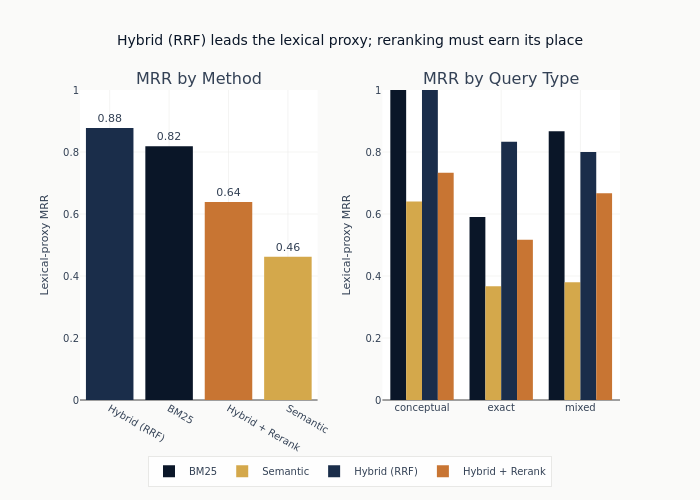

In [34]:
for method in method_order:
    subset = by_type.filter(pl.col("method") == method)
    fig.add_trace(
        go.Bar(
            name=method,
            x=subset["query_type"].to_list(),
            y=subset["avg_mrr"].to_list(),
            marker_color=colors[method],
        ),
        row=1,
        col=2,
    )

fig.update_layout(
    title=(f"{best_proxy_row['method']} leads the lexical proxy; reranking must earn its place"),
    height=500,
    showlegend=True,
    legend=dict(orientation="h", yanchor="top", y=-0.18, xanchor="center", x=0.5),
    barmode="group",
    margin=dict(t=90, b=100),
)

fig.update_yaxes(title_text="Lexical-proxy MRR", range=[0, 1], row=1, col=1)
fig.update_yaxes(title_text="Lexical-proxy MRR", range=[0, 1], row=1, col=2)

fig.show()

**Interpretation**: The by-type breakdown shows that a single aggregate hides
different proxy behavior. Reranking changes the order but does not improve the
lexical-proxy score in this run; human labels decide whether that change helps.

## 9. Query Enhancement: HyDE

**Hypothetical Document Embeddings (HyDE)** generates a hypothetical answer to
the query using an LLM, then embeds that answer instead of the raw query.
This bridges the vocabulary gap between how analysts phrase questions and how
documents express the same information.

**HyDE Workflow**:
1. **Query**: "What are the supply chain risks?"
2. **LLM generates hypothetical answer**: "The company faces significant supply
   chain risks including geographic concentration in Asia..."
3. **Embed the hypothetical answer** (not the original query)
4. **Retrieve documents** similar to the hypothetical answer

**Intended benefit**: bridge a vocabulary gap by embedding an answer-shaped
query representation. This notebook does not implement or measure HyDE.

**Trade-offs**: Adds LLM latency to retrieval, risk of hallucinated hypothetical
affecting retrieval quality. Best combined with keyword search as fallback.

## 10. Key Insights

### When to Use Each Method

| Query Pattern | Candidate to test | Examples |
|---------------|-------------------|----------|
| Exact symbols, form numbers | BM25 | "AAPL 10-K", "Form 8-K" |
| Exact figures, dates | BM25 | "Q4 2023 revenue", "$89.5 billion" |
| Conceptual questions | Semantic | "What are the risks?", "How profitable?" |
| Paraphrased queries | Semantic | "profit margins" vs "gross margin" |
| Mixed requirements | Hybrid, then tested reranking | "Apple supply chain Asia risk" |

### Production Recommendations

1. **Treat hybrid retrieval as a candidate first stage** - Verify it on human
   relevance judgments before deployment.

2. **Gate reranking on human labels** - A second-stage re-ranker changes the
   ordering and adds latency; it belongs only when judged relevance improves.

3. **Tune the RRF k parameter** - Keep the query labels fixed while testing
   how rank fusion changes the result.

4. **Evaluate HyDE for open-ended queries** - It adds generation latency and
   can inject unsupported concepts, so compare it on the same judged set.

In [35]:
# Summary statistics
print("=== Hybrid Retrieval Summary ===\n")

if len(overall) >= 2:
    hybrid_mrr = overall.filter(pl.col("method") == "Hybrid (RRF)")["avg_mrr"].to_list()
    rerank_mrr = overall.filter(pl.col("method") == "Hybrid + Rerank")["avg_mrr"].to_list()
    bm25_mrr = overall.filter(pl.col("method") == "BM25")["avg_mrr"].to_list()
    semantic_mrr = overall.filter(pl.col("method") == "Semantic")["avg_mrr"].to_list()

    if hybrid_mrr and rerank_mrr and bm25_mrr and semantic_mrr:
        hybrid_val = hybrid_mrr[0]
        rerank_val = rerank_mrr[0]
        best_single = max(bm25_mrr[0], semantic_mrr[0])
        improvement = (hybrid_val - best_single) / best_single * 100
        rerank_improvement = (rerank_val - hybrid_val) / hybrid_val * 100 if hybrid_val else 0.0

        print(f"Hybrid (RRF) MRR: {hybrid_val:.3f}")
        print(f"Hybrid + rerank MRR: {rerank_val:.3f}")
        print(f"Best single method MRR: {best_single:.3f}")
        print(f"Hybrid vs best single: {improvement:.1f}%")
        print(f"Rerank vs hybrid: {rerank_improvement:.1f}%")
        print(f"\nRRF constant k={hybrid.rrf_k}")
        print(f"Re-ranker backend: {reranker.backend}")
        print(f"Documents in corpus: {len(documents)}")
        print(f"Queries evaluated: {len(TEST_QUERIES)}")
else:
    print("Insufficient data for summary")

=== Hybrid Retrieval Summary ===

Hybrid (RRF) MRR: 0.878
Hybrid + rerank MRR: 0.639
Best single method MRR: 0.819
Hybrid vs best single: 7.2%
Rerank vs hybrid: -27.2%

RRF constant k=60
Re-ranker backend: cross_encoder
Documents in corpus: 200
Queries evaluated: 15


### Production Vector Database Support

| Database | Hybrid Support | Notes |
|----------|----------------|-------|
| Pinecone | Native | sparse_values + dense vectors |
| Weaviate | Native | BM25F + vector with alpha blend |
| Qdrant | Native | Sparse + dense with RRF fusion |
| Milvus | Native | Sparse-dense hybrid index |
| ChromaDB | Manual | Requires external BM25 + fusion |
| pgvector | Manual | Combine with pg_trgm for keywords |

LlamaIndex and LangChain provide abstractions for hybrid search
that work across multiple backends.

**Interpretation**: The summary statistics and backend options point to the
same conclusion: hybrid retrieval is most useful as a configurable production
pattern, not as a single fixed recipe.

## Key Takeaways

1. **Hybrid retrieval is a first-stage recall mechanism.** Combining BM25
   and semantic search exposes the candidate pool to both exact identifiers
   and paraphrased concepts. The computed summary above reports how each
   variant agrees with this notebook's lexical proxy.
2. **BM25 remains essential** for financial documents: exact symbols,
   form numbers, exact dollar figures, and dates are explicit lexical signals
   that dense retrieval should not be expected to preserve perfectly.
3. **Reranking is a production pattern, not a guaranteed gain.** The
   cross-encoder changes a finance-domain candidate list, but only a judged
   relevance set can establish whether the new order is better.
4. **RRF combines ranks without calibrating score scales.** The smoothing
   constant $k=60$ is a visible parameter and should be tested when labels
   are available.
5. **HyDE remains an unmeasured extension here.** Its vocabulary-bridging
   hypothesis and hallucination risk need a separate controlled evaluation.

**Next**: See [`04_ragas_evaluation`](04_ragas_evaluation.ipynb) for systematic evaluation of full
RAG pipelines using retrieval, grounding, abstention, and security metrics.

**Book Reference**: Section 22.5 covers hybrid retrieval architectures,
RRF derivation, and vector database selection criteria.